In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [2]:
data=pd.read_csv(r"C:\Users\Pravalika.b\Downloads\netflix.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Dataset Shape:",data.shape)
print("\n Columns:")
print("\n Data Types:")
print(data.dtypes)

Dataset Shape: (8807, 12)

 Columns:

 Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8804,15-Aug,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,1-Jan-20,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
## Checking missing values
missing=data.isnull().sum().sort_values(ascending=False)
missing_data=pd.DataFrame({
    "Missing Values": missing,
    "Missing %":(missing/len(data)*100).round(2)
})
missing_data

,Missing Values,Missing %
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [7]:
## Check duplicates
print("duplicate rows:",data.duplicated().sum())

duplicate rows: 0


In [8]:
data=data.drop_duplicates()
print("shape after removing duplicates:",data.shape)

shape after removing duplicates: (8807, 12)


In [9]:
## clean important columns
data["country"]=data["country"].fillna("Unknown")
data["rating"]=data["rating"].fillna("Unkonown")
data["director"]=data["director"].fillna("Unknown")
data["cast"]=data["cast"].fillna("Unknown")
data["listed_in"]=data["listed_in"].fillna("Unkonwn")

In [10]:
## Check content types
data["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

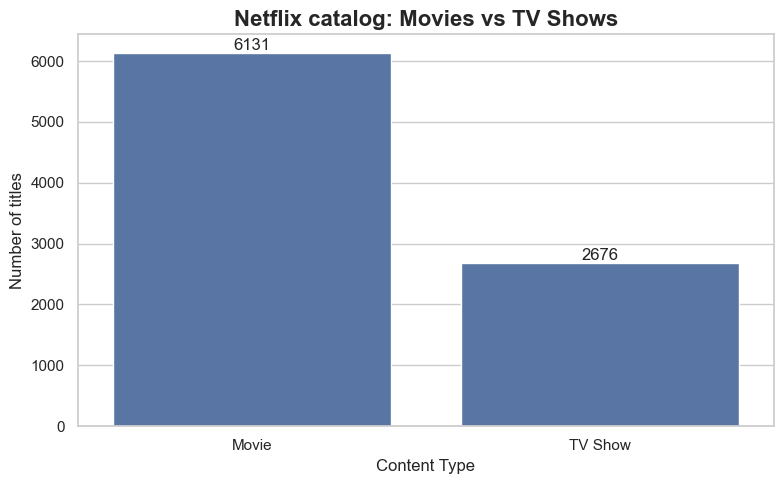

In [11]:
## Movies vs TV Shows
type_counts=data["type"].value_counts()
plt.figure(figsize=(8,5))
ax=sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)
plt.title("Netflix catalog: Movies vs TV Shows", fontsize=16,fontweight="bold")
plt.xlabel("Content Type")
plt.ylabel("Number of titles")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

In [12]:
## Release-year analysis 
data["release_year"].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [13]:
yearly_releases=(
    data.groupby("release_year")
    .size()
    .reset_index(name="title_count")
)
yearly_releases.head()

,release_year,title_count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


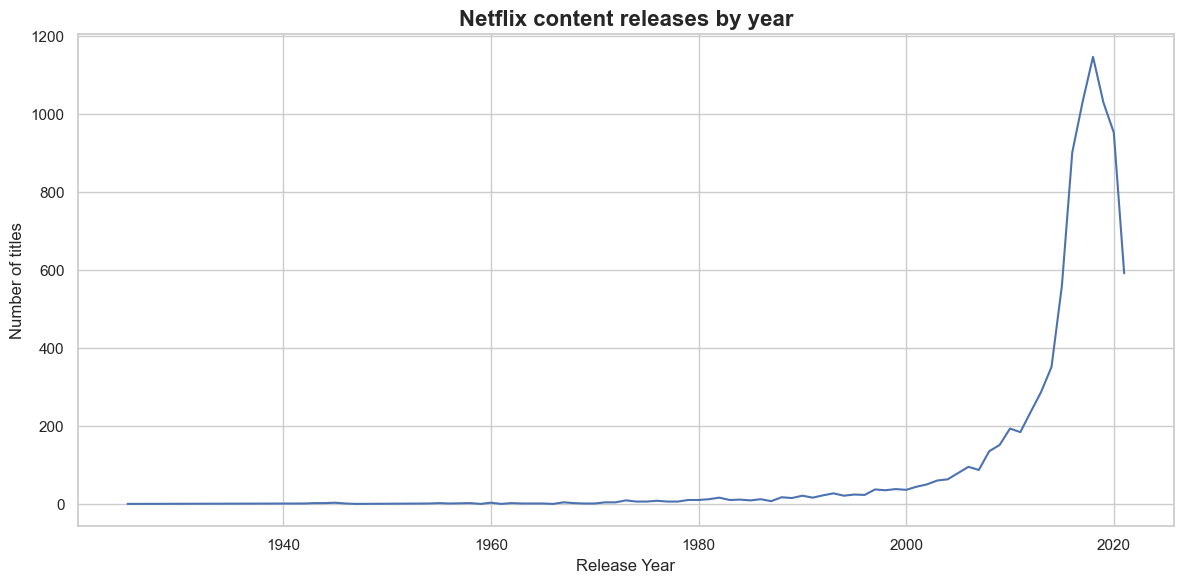

In [14]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=yearly_releases,
    x="release_year",
    y="title_count"
)
plt.title("Netflix content releases by year",fontsize=16,fontweight="bold")
plt.xlabel("Release Year")
plt.ylabel("Number of titles")
plt.tight_layout()
plt.show()

In [15]:
## Genre analysis
genre_data=data[["title","type","release_year","listed_in"]].copy()
genre_data["genre"]=genre_data["listed_in"].str.split(", ")
genre_data=genre_data.explode("genre")
genre_data.head()

,title,type,release_year,listed_in,genre
0,Dick Johnson Is Dead,Movie,2020,Documentaries,Documentaries
1,Blood & Water,TV Show,2021,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows
1,Blood & Water,TV Show,2021,"International TV Shows, TV Dramas, TV Mysteries",TV Dramas
1,Blood & Water,TV Show,2021,"International TV Shows, TV Dramas, TV Mysteries",TV Mysteries
2,Ganglands,TV Show,2021,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows


In [16]:
genre_counts=(
    genre_data["genre"]
    .value_counts()
    .reset_index()
)
genre_counts.columns=["genre","title_count"]
genre_counts.head(10)

,genre,title_count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869
5,Action & Adventure,859
6,TV Dramas,763
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


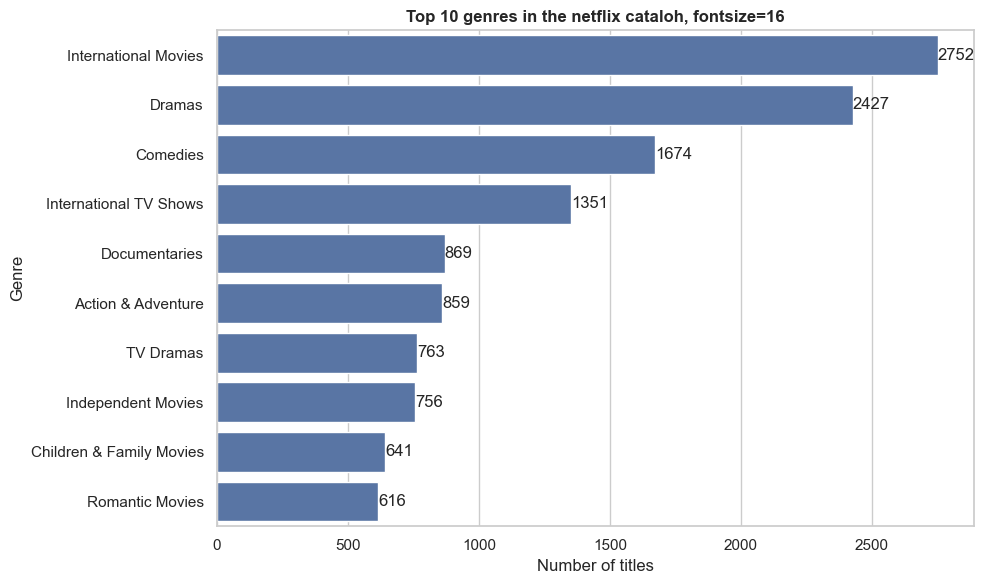

In [17]:
## Top 10 genres
top_genres=genre_counts.head(10)
plt.figure(figsize=(10,6))
ax=sns.barplot(
    data=top_genres,
    y="genre",
    x="title_count"
)
plt.title("Top 10 genres in the netflix cataloh, fontsize=16",fontweight="bold")
plt.xlabel("Number of titles")
plt.ylabel("Genre")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

In [18]:
## Genre mix over time
top_5_genres=genre_counts.head(5)["genre"].tolist()
genre_trend=(
    genre_data[genre_data["genre"].isin(top_5_genres)]
    .groupby(["release_year","genre"])
    .size()
    .reset_index(name="title_count")
)

In [19]:
genre_trend_recent=genre_trend[
    genre_trend["release_year"]>=2010
]

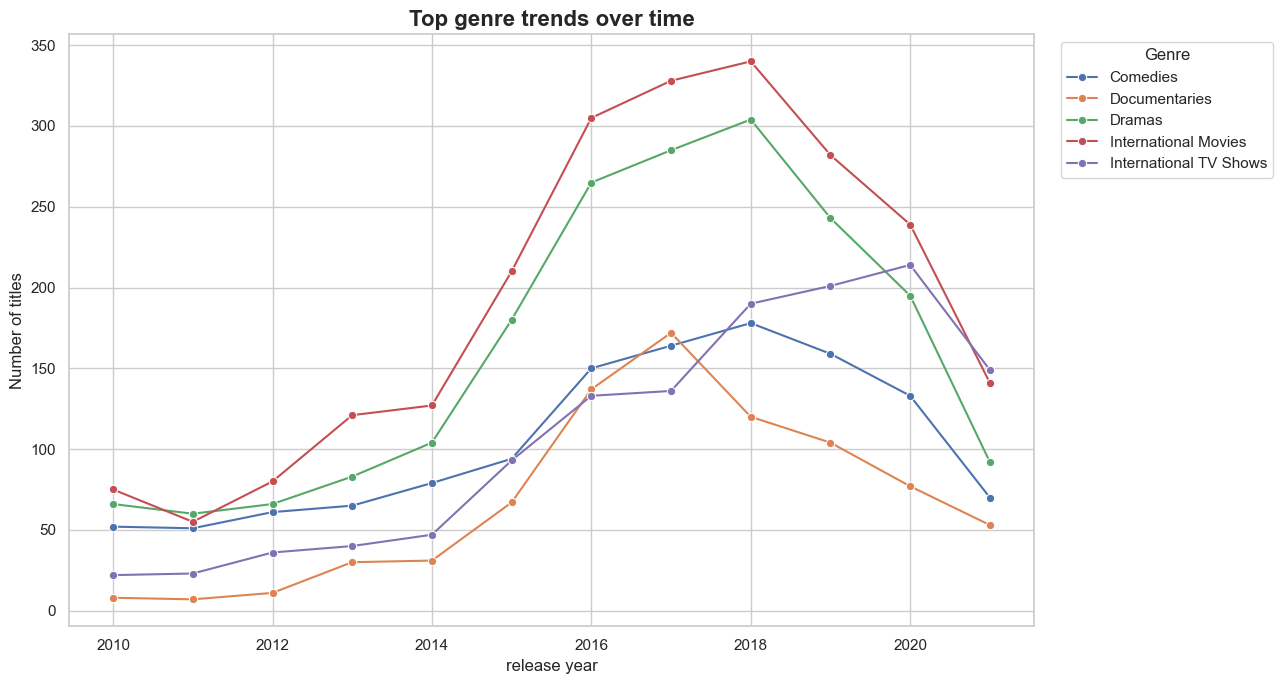

In [20]:
## Genre mix over time
plt.figure(figsize=(13,7))
sns.lineplot(
    data=genre_trend_recent,
    x="release_year",
    y="title_count",
    hue="genre",
    marker="o"
)
plt.title("Top genre trends over time",fontsize=16,fontweight="bold")
plt.xlabel("release year")
plt.ylabel("Number of titles")
plt.legend(title="Genre",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
## Rating analysis
rating_counts=(
    data["rating"]
    .value_counts()
    .reset_index()
)
rating_counts.columns=["rating","title_count"]
rating_counts

,rating,title_count
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


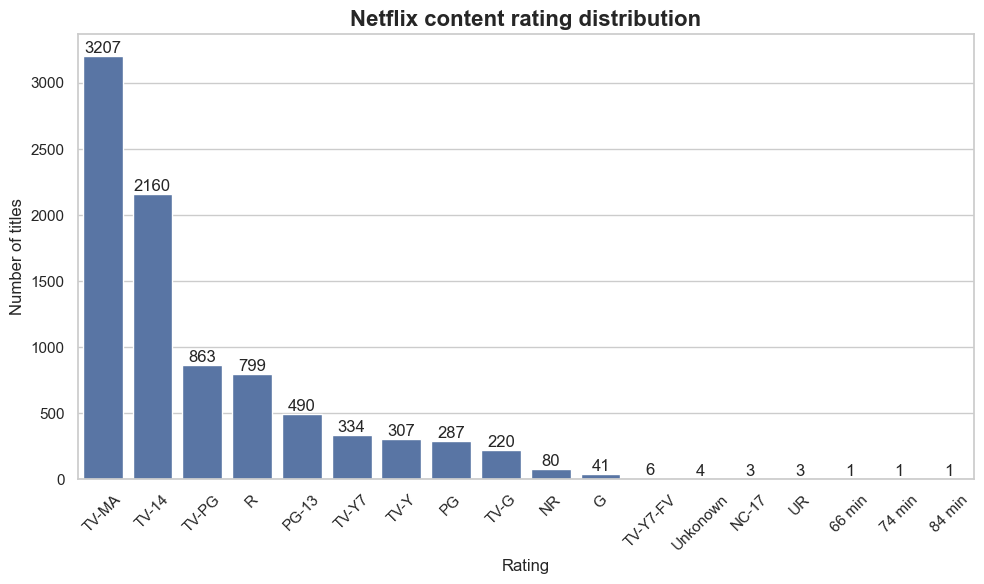

In [22]:
## Content ratings
plt.figure(figsize=(10,6))
ax=sns.barplot(
    data=rating_counts,
    x="rating",
    y="title_count"
)
plt.title("Netflix content rating distribution",fontsize=16,fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of titles")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


In [23]:
## Country analysis
country_data=data[["title","type","release_year","country"]].copy()
country_data=country_data.dropna(subset=["country"])
country_data["country_clean"]=country_data["country"].str.split(", ")
country_data=country_data.explode("country_clean")
country_counts=(country_data["country_clean"]
                .value_counts()
                .reset_index()
                )
country_counts.columns=["country","title_count"]
top_countries=country_counts.head(10)
print(top_countries)

          country  title_count
0   United States         3689
1           India         1046
2         Unknown          831
3  United Kingdom          804
4          Canada          445
5          France          393
6           Japan          318
7           Spain          232
8     South Korea          231
9         Germany          226


In [24]:
# Country Analysis

# Reload the original dataset
data = pd.read_csv(
    r"C:\Users\Pravalika.b\Downloads\netflix.csv"
)

# Check country data
print("Total rows:", len(data))
print("Countries available:", data["country"].notna().sum())

# Select required columns
country_data = data[["title", "type", "release_year", "country"]].copy()

# Remove rows where country is missing
country_data = country_data.dropna(subset=["country"])

# Split multiple countries
country_data["country_clean"] = country_data["country"].str.split(", ")

# Create one row per country
country_data = country_data.explode("country_clean")

# Count titles by country
country_counts = (
    country_data["country_clean"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["country", "title_count"]

# Sort highest to lowest
country_counts = country_counts.sort_values(
    "title_count",
    ascending=False
)


top_countries = country_counts.head(10)

print(top_countries)

Total rows: 8807
Countries available: 7976
          country  title_count
0   United States         3689
1           India         1046
2  United Kingdom          804
3          Canada          445
4          France          393
5           Japan          318
6           Spain          232
7     South Korea          231
8         Germany          226
9          Mexico          169


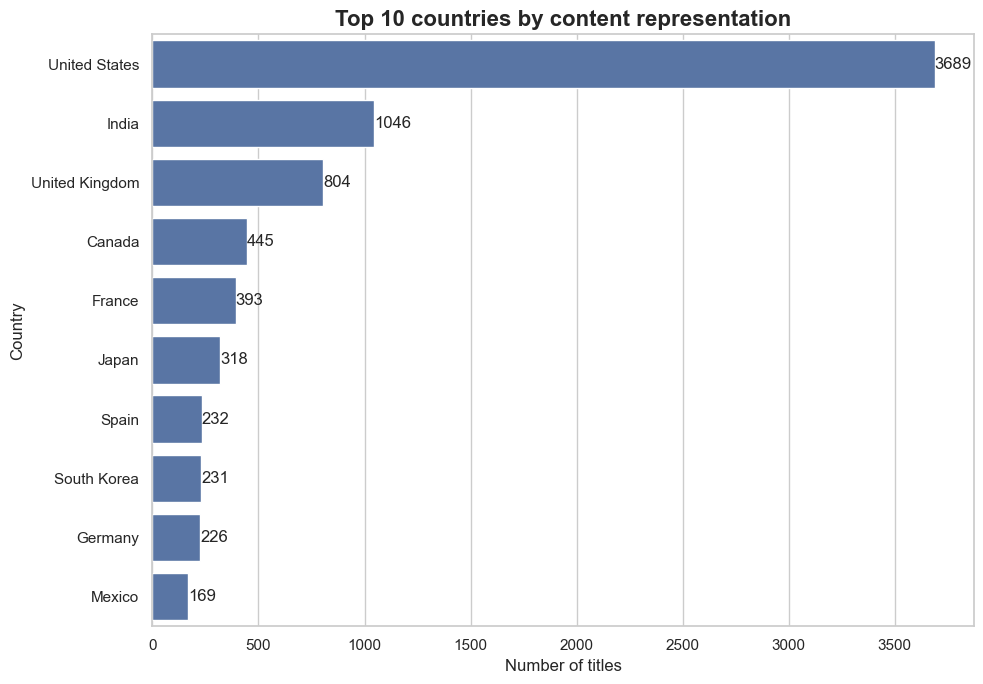

In [25]:
## Regional content mix

plt.figure(figsize=(10,7))
ax=sns.barplot(
    data=top_countries,
    y="country",
    x="title_count"
)
plt.title("Top 10 countries by content representation", fontsize=16,fontweight="bold")
plt.xlabel("Number of titles")
plt.ylabel("Country")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

In [26]:
## Movie duration
data["duration_number"]=(
    data["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [27]:
data[["type","duration","duration_number"]].head(10)

,type,duration,duration_number
0,Movie,90 min,90.0
1,TV Show,2 Seasons,2.0
2,TV Show,1 Season,1.0
3,TV Show,1 Season,1.0
4,TV Show,2 Seasons,2.0
5,TV Show,1 Season,1.0
6,Movie,91 min,91.0
7,Movie,125 min,125.0
8,TV Show,9 Seasons,9.0
9,Movie,104 min,104.0


In [28]:
movies=data[data["type"]=="Movie"].copy()

In [29]:
## Average movie duaration over time
movie_duration_trend=(
    movies.groupby("release_year")["duration_number"]
    .mean()
    .reset_index()
)
movie_duration_trend.columns=[
    "release_year",
    "avg_duration"
]

In [30]:
movie_duration_recent=movie_duration_trend[
    movie_duration_trend["release_year"]>=200
]

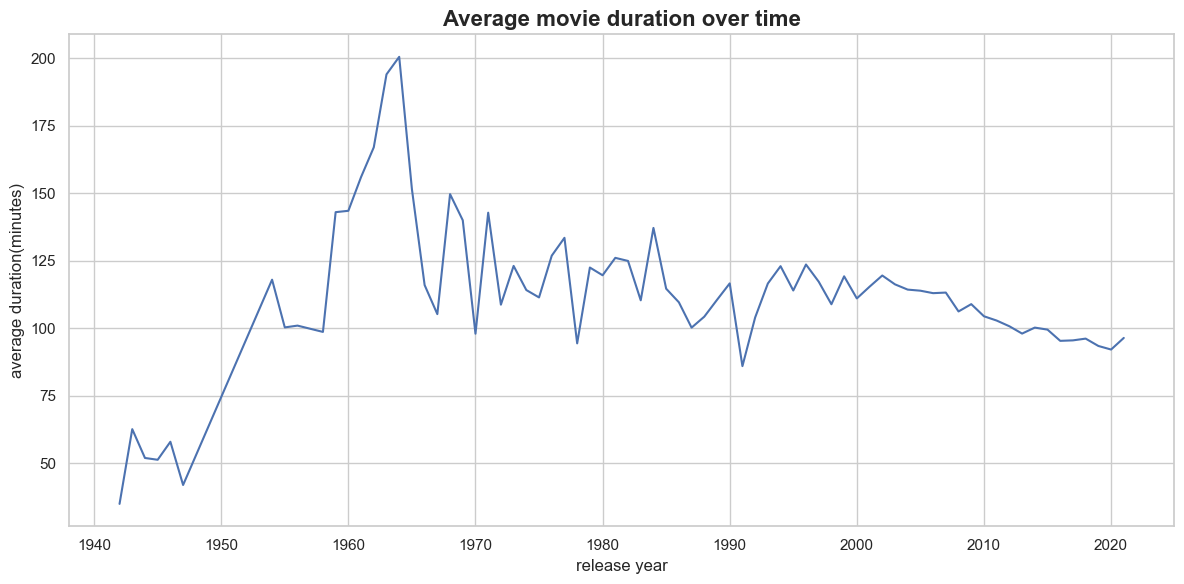

In [31]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=movie_duration_recent,
    x="release_year",
    y="avg_duration"
)
plt.title("Average movie duration over time",fontsize=16,fontweight="bold")
plt.xlabel("release year")
plt.ylabel("average duration(minutes)")
plt.tight_layout()
plt.show()

In [32]:
## TV-show seasons
tv_shows=data[data["type"]=="TV Show"].copy()

In [33]:
tv_shows["seasons"]=(
    tv_shows["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [34]:
tv_shows[["title","duration","seasons"]].head(10)

,title,duration,seasons
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0
8,The Great British Baking Show,9 Seasons,9.0
10,"Vendetta: Truth, Lies and The Mafia",1 Season,1.0
11,Bangkok Breaking,1 Season,1.0
14,Crime Stories: India Detectives,1 Season,1.0
15,Dear White People,4 Seasons,4.0


In [35]:
season_trend=(
    tv_shows.groupby("release_year")["seasons"]
    .mean()
    .reset_index()
)
season_trend.columns=[
    "release_year",
    "avg_seasons"]

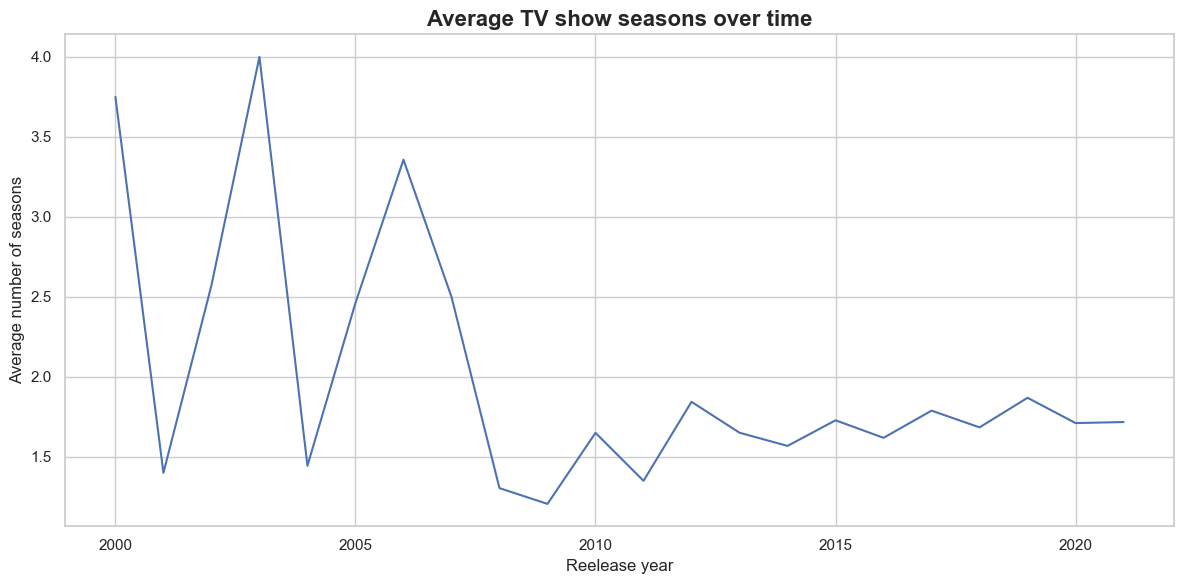

In [37]:
## TV seasons trend
season_trend_recent=season_trend[
    season_trend["release_year"]>=2000
]
plt.figure(figsize=(12,6))
sns.lineplot(
    data=season_trend_recent,
    x="release_year",
    y="avg_seasons"
)
plt.title("Average TV show seasons over time",fontsize=16,fontweight="bold")
plt.xlabel("Reelease year")
plt.ylabel("Average number of seasons")
plt.tight_layout()
plt.show()

In [38]:
## Additional analysis- Movie vs Tv by year
type_year=(
    data.groupby(["release_year","type"])
    .size()
    .reset_index(name="title_count")
)
type_year_recent=type_year[
    type_year["release_year"]>=2010
]

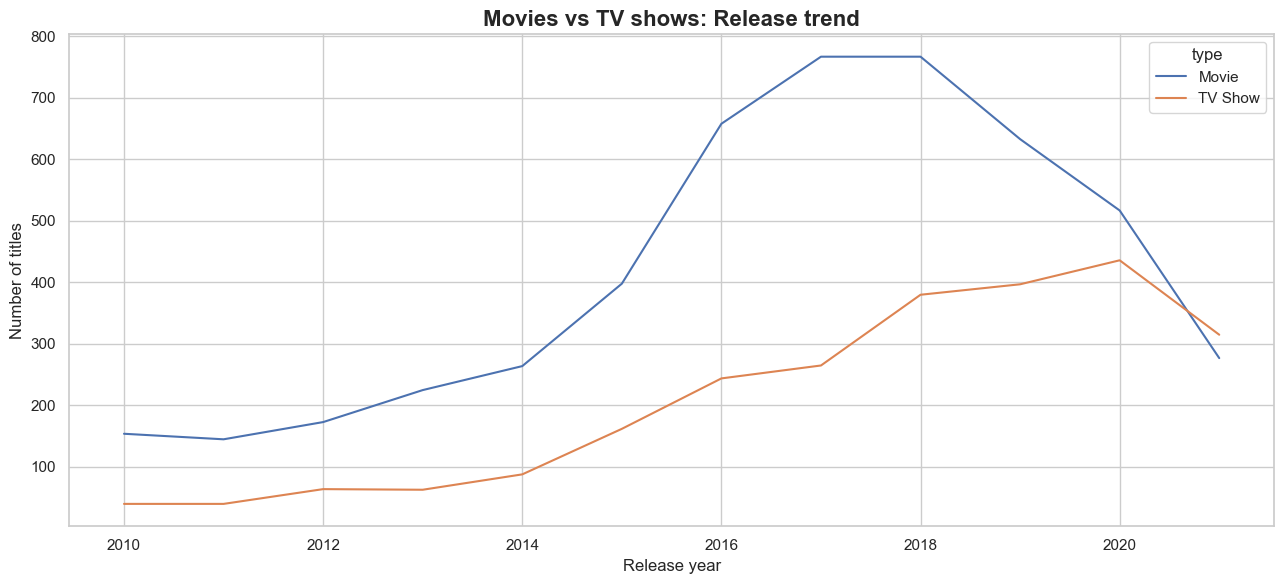

In [39]:
plt.figure(figsize=(13,6))
sns.lineplot(
    data=type_year_recent,
    x="release_year",
    y="title_count",
    hue="type"
)
plt.title("Movies vs TV shows: Release trend",fontsize=16,fontweight="bold")
plt.xlabel("Release year")
plt.ylabel("Number of titles")
plt.tight_layout()
plt.show()

In [40]:
## most popular genres
print("Top 10 Genres:")
print(genre_counts.head(10))

Top 10 Genres:
                      genre  title_count
0      International Movies         2752
1                    Dramas         2427
2                  Comedies         1674
3    International TV Shows         1351
4             Documentaries          869
5        Action & Adventure          859
6                 TV Dramas          763
7        Independent Movies          756
8  Children & Family Movies          641
9           Romantic Movies          616


In [41]:
## Most represented countries
print("Top 10 countries:")
print(country_counts.head(10))

Top 10 countries:
          country  title_count
0   United States         3689
1           India         1046
2  United Kingdom          804
3          Canada          445
4          France          393
5           Japan          318
6           Spain          232
7     South Korea          231
8         Germany          226
9          Mexico          169


In [42]:
## Most common ratings
print("Content Ratings:")
print(rating_counts.head(10))

Content Ratings:
  rating  title_count
0  TV-MA         3207
1  TV-14         2160
2  TV-PG          863
3      R          799
4  PG-13          490
5  TV-Y7          334
6   TV-Y          307
7     PG          287
8   TV-G          220
9     NR           80


In [43]:
## Average movie duration
print("Average movie duartion:",round(movies["duration_number"].mean(),2),"minutes")

Average movie duartion: 99.58 minutes


In [44]:
## Average TV seasons
print("Average TV seasons:",round(tv_shows["seasons"].mean(),2),)

Average TV seasons: 1.76


In [45]:
## Automatically identify some key findings


In [46]:
## Largest genre
largest_genre=genre_counts.iloc[0]
print("largest genre:",
      largest_genre["genre"],
      "-",
      largest_genre["title_count"],
      "titles")

largest genre: International Movies - 2752 titles


In [47]:
## largest country
largest_country=country_counts.iloc[0]
print("largest content market:",
      largest_country["country"],
      "-",
      largest_country["title_count"],
      "titles")

largest content market: United States - 3689 titles


In [48]:
## most coomon ratings
most_common_rating=rating_counts.iloc[0]
print("most common rating:",
      most_common_rating["rating"],
      "-",
      most_common_rating["title_count"],
      "titles")

most common rating: TV-MA - 3207 titles
